# Import libraries

In [25]:
import neurokit2 as nk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline

from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
import time
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize

import torch
from CNN_extractor import CNNFeatureExtractor
from Autoencoder import Autoencoder

# Load data

In [26]:
df = pd.read_parquet("../data/ptbxl100_single.parquet")
df.head()

,patient_id,diagnostic_superclass,signal
ecg_id,,,
1,15709.0,NORM,"[-0.119, -0.055, 0.064, 0.086, -0.091, 0.004, ..."
2,13243.0,NORM,"[0.004, 0.138, 0.134, -0.072, -0.065, 0.136, -..."
3,20372.0,NORM,"[-0.029, -0.079, -0.049, 0.054, 0.011, -0.064,..."
4,17014.0,NORM,"[-0.054, -0.138, -0.083, 0.096, 0.015, -0.11, ..."
5,17448.0,NORM,"[-0.034, -0.574, -0.54, 0.304, 0.253, -0.556, ..."


In [27]:
LEADS = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

X = np.stack(df["signal"].values)
y = df["diagnostic_superclass"]

print(f"X: {X.shape}")
print(f"y: {y.shape}  {y.nunique()} classes")

X: (16244, 12000)
y: (16244,)  5 classes


# `neurokit2` Feature Extraction

Unlike `reproduction.ipynb` and `ablation.ipynb`, we shall apply `neurokit2` to each lead separately, and concatenate then afterwards.

Following III.D, the script finds the R peaks with `ecg_peaks()`, locates P, Q, S and T around them with `ecg_delineate(method = "peak")`, and assembles the sixteen features, i.e. five peak locations, five peak amplitudes, and six intervals (PQ, ST, QT, PR, RR, QRS).

**Run the first block** if the parquet is already there. **If it is not, run the second block first**, then come back to the first.

We shall note, the additional column is the label, not the features of our interests.

In [28]:
# Block 1: the parquet already exists.
ORDERING = "perlead"          # twelve passes, one per 1000-sample lead
FEATURES_PATH = f"../data/features_{ORDERING}.parquet"

features = pd.read_parquet(FEATURES_PATH)

print(f"loaded {features.shape[0]:,} records from {FEATURES_PATH}")
print(f"features shape is: {features.shape}")
features.head(2)

loaded 16,244 records from ../data/features_perlead.parquet
features shape is: (16244, 193)


,I_P_loc,I_Q_loc,I_R_loc,I_S_loc,I_T_loc,I_P_amp,I_Q_amp,I_R_amp,I_S_amp,I_T_amp,...,V6_R_amp,V6_S_amp,V6_T_amp,V6_PQ,V6_ST,V6_QT,V6_PR,V6_QRS,V6_RR,label
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,"[100.0, 195.0, 290.0, 381.0, 477.0, 570.0, 667...","[111.0, 204.0, 298.0, 389.0, 483.0, 580.0, 675...","[115.0, 208.0, 300.0, 393.0, 488.0, 583.0, 679...","[121.0, 211.0, 304.0, 400.0, 492.0, 588.0, 692...","[143.0, 235.0, 328.0, 422.0, 515.0, 611.0, 707...","[-0.051, 0.013, 0.125, 0.094, 0.155, 0.128, 0....","[-0.152, -0.101, -0.033, -0.024, -0.068, -0.05...","[0.521, 0.559, 0.628, 0.641, 0.572, 0.622, 0.6...","[-0.157, -0.106, -0.045, -0.051, -0.046, -0.02...","[0.072, 0.11, 0.182, 0.161, 0.184, 0.156, 0.19...",...,"[0.409, 0.472, 0.444, 0.432, 0.369, 0.325, 0.3...","[-0.021, 0.025, 0.0, -0.03, -0.096, -0.138, -0...","[0.182, 0.198, 0.189, 0.16, 0.092, 0.068, 0.22...","[9.0, 9.0, 7.0, 8.0, 5.0, 8.0, 7.0, 9.0, 7.0, ...","[17.0, 16.0, 13.0, 14.0, 12.0, 11.0, 19.0, 19....","[31.0, 30.0, 31.0, 31.0, 33.0, 31.0, 35.0, 31....","[12.0, 12.0, 11.0, 12.0, 11.0, 11.0, 14.0, 12....","[14.0, 14.0, 18.0, 17.0, 21.0, 20.0, 16.0, 12....","[nan, 93.0, 93.0, 93.0, 94.0, 95.0, 97.0, 94.0...",NORM
2,"[87.0, 217.0, 354.0, 488.0, 614.0, 733.0, 849.0]","[97.0, 227.0, 364.0, 498.0, 622.0, 739.0, 859.0]","[100.0, 231.0, 368.0, 502.0, 627.0, 747.0, 863.0]","[102.0, 233.0, 370.0, 504.0, 629.0, 749.0, 865.0]","[128.0, 259.0, 395.0, 528.0, 655.0, 773.0, 889.0]","[0.049, 0.125, 0.153, 0.011, -0.003, 0.013, 0.03]","[-0.101, 0.002, 0.027, -0.112, -0.146, -0.107,...","[0.526, 0.601, 0.664, 0.504, 0.563, 0.543, 0.637]","[-0.265, -0.209, -0.158, -0.349, -0.224, -0.34...","[0.383, 0.512, 0.434, 0.33, 0.334, 0.352, 0.428]",...,"[1.266, 1.394, 1.328, 1.26, 1.317, 1.391, 1.177]","[-0.006, -0.018, -0.126, -0.034, 0.041, -0.037...","[0.3, 0.304, 0.237, 0.413, 0.437, 0.373, 0.389]","[12.0, 11.0, 12.0, 8.0, 11.0, 11.0, 10.0]","[24.0, 25.0, 26.0, 25.0, 25.0, 26.0, 25.0]","[29.0, 30.0, 31.0, 48.0, 31.0, 31.0, 31.0]","[14.0, 13.0, 14.0, 27.0, 14.0, 13.0, 12.0]","[5.0, 5.0, 5.0, 23.0, 6.0, 5.0, 6.0]","[nan, 130.0, 137.0, 134.0, 126.0, 119.0, 116.0]",NORM


In [29]:
# Block 2: No parquet yet. Re-extracts from ptbxl100_single.parquet
# !python ../src/extract_nk_features.py perlead

In [30]:
shapes = []

for i in range(features.shape[0]):
    for j in range(features.shape[1] - 1):
        # print(i, j, features.iloc[i, j])
        shapes.append(features.iloc[i, j].shape)

np.unique(shapes)


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

In [31]:
features.head(2)

,I_P_loc,I_Q_loc,I_R_loc,I_S_loc,I_T_loc,I_P_amp,I_Q_amp,I_R_amp,I_S_amp,I_T_amp,...,V6_R_amp,V6_S_amp,V6_T_amp,V6_PQ,V6_ST,V6_QT,V6_PR,V6_QRS,V6_RR,label
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,"[100.0, 195.0, 290.0, 381.0, 477.0, 570.0, 667...","[111.0, 204.0, 298.0, 389.0, 483.0, 580.0, 675...","[115.0, 208.0, 300.0, 393.0, 488.0, 583.0, 679...","[121.0, 211.0, 304.0, 400.0, 492.0, 588.0, 692...","[143.0, 235.0, 328.0, 422.0, 515.0, 611.0, 707...","[-0.051, 0.013, 0.125, 0.094, 0.155, 0.128, 0....","[-0.152, -0.101, -0.033, -0.024, -0.068, -0.05...","[0.521, 0.559, 0.628, 0.641, 0.572, 0.622, 0.6...","[-0.157, -0.106, -0.045, -0.051, -0.046, -0.02...","[0.072, 0.11, 0.182, 0.161, 0.184, 0.156, 0.19...",...,"[0.409, 0.472, 0.444, 0.432, 0.369, 0.325, 0.3...","[-0.021, 0.025, 0.0, -0.03, -0.096, -0.138, -0...","[0.182, 0.198, 0.189, 0.16, 0.092, 0.068, 0.22...","[9.0, 9.0, 7.0, 8.0, 5.0, 8.0, 7.0, 9.0, 7.0, ...","[17.0, 16.0, 13.0, 14.0, 12.0, 11.0, 19.0, 19....","[31.0, 30.0, 31.0, 31.0, 33.0, 31.0, 35.0, 31....","[12.0, 12.0, 11.0, 12.0, 11.0, 11.0, 14.0, 12....","[14.0, 14.0, 18.0, 17.0, 21.0, 20.0, 16.0, 12....","[nan, 93.0, 93.0, 93.0, 94.0, 95.0, 97.0, 94.0...",NORM
2,"[87.0, 217.0, 354.0, 488.0, 614.0, 733.0, 849.0]","[97.0, 227.0, 364.0, 498.0, 622.0, 739.0, 859.0]","[100.0, 231.0, 368.0, 502.0, 627.0, 747.0, 863.0]","[102.0, 233.0, 370.0, 504.0, 629.0, 749.0, 865.0]","[128.0, 259.0, 395.0, 528.0, 655.0, 773.0, 889.0]","[0.049, 0.125, 0.153, 0.011, -0.003, 0.013, 0.03]","[-0.101, 0.002, 0.027, -0.112, -0.146, -0.107,...","[0.526, 0.601, 0.664, 0.504, 0.563, 0.543, 0.637]","[-0.265, -0.209, -0.158, -0.349, -0.224, -0.34...","[0.383, 0.512, 0.434, 0.33, 0.334, 0.352, 0.428]",...,"[1.266, 1.394, 1.328, 1.26, 1.317, 1.391, 1.177]","[-0.006, -0.018, -0.126, -0.034, 0.041, -0.037...","[0.3, 0.304, 0.237, 0.413, 0.437, 0.373, 0.389]","[12.0, 11.0, 12.0, 8.0, 11.0, 11.0, 10.0]","[24.0, 25.0, 26.0, 25.0, 25.0, 26.0, 25.0]","[29.0, 30.0, 31.0, 48.0, 31.0, 31.0, 31.0]","[14.0, 13.0, 14.0, 27.0, 14.0, 13.0, 12.0]","[5.0, 5.0, 5.0, 23.0, 6.0, 5.0, 6.0]","[nan, 130.0, 137.0, 134.0, 126.0, 119.0, 116.0]",NORM


## Visualisations waveforms amplitudes and their peak locations

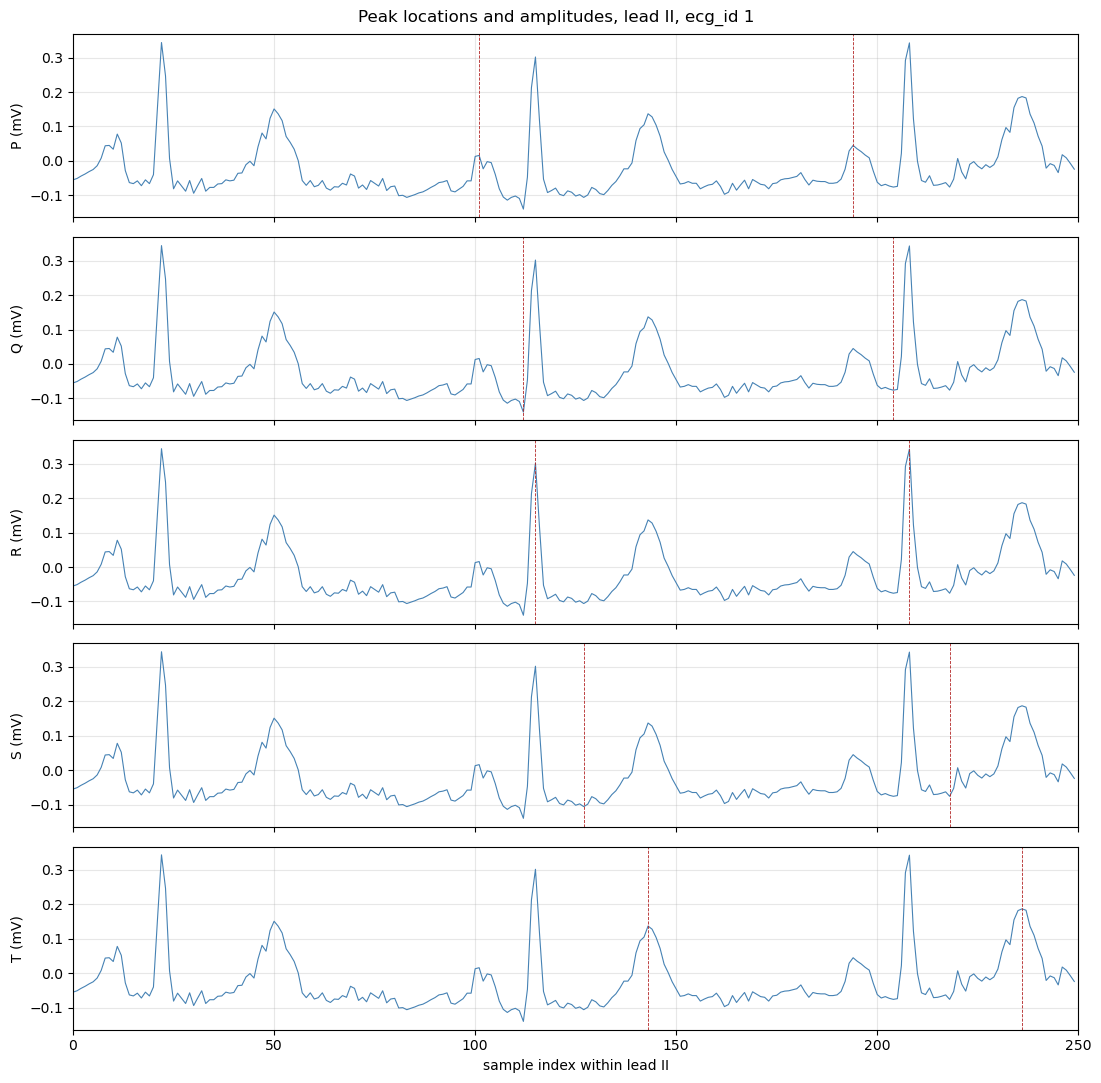

In [32]:
sample = features.iloc[0]

# Per-lead columns are prefixed, so the visualisations below pick one lead.
LEAD = "II"
signal = X[0].reshape(1000, 12)[:, LEADS.index(LEAD)]

# Visualise five waveform amplitudes (in blue) and their peaks (in red)
WAVE_LABELS = ["P", "Q", "R", "S", "T"]

window = 250

fig, axes = plt.subplots(len(WAVE_LABELS), 1, figsize = (11, 11), sharex = True)

for ax, wave in zip(axes, WAVE_LABELS):
    ax.plot(np.arange(window), signal[:window], color = "steelblue", linewidth = 0.8)

    location = sample[f"{LEAD}_{wave}_loc"]
    amplitude = sample[f"{LEAD}_{wave}_amp"]

    for x in location:
        ax.axvline(x, color = "firebrick", linestyle = "--", linewidth = 0.6, alpha = 1)

    ax.set_ylabel(f"{wave} (mV)")
    ax.set_xlim(0, window)
    ax.grid(alpha = 0.3)
    ax.set_axisbelow(True)

axes[-1].set_xlabel(f"sample index within lead {LEAD}")
fig.suptitle(f"Peak locations and amplitudes, lead {LEAD}, ecg_id {sample.name}")

plt.tight_layout()
plt.show()

## Visualisations of intervals/segments

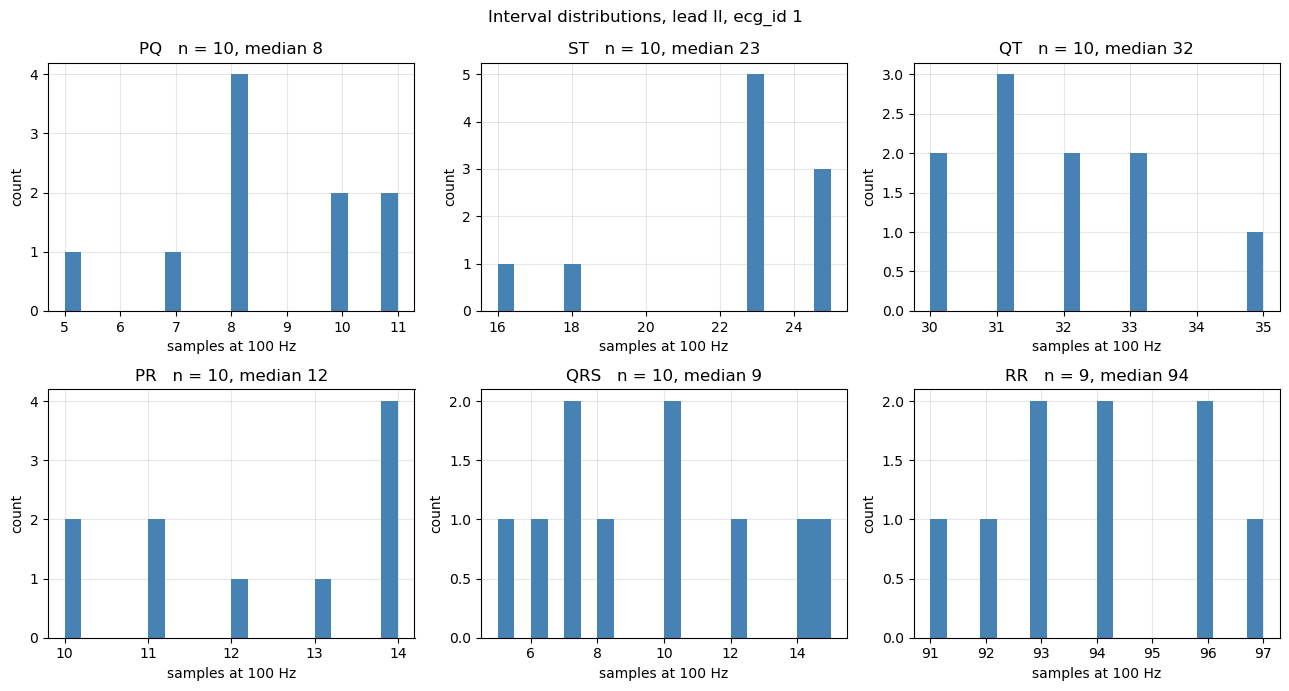

In [33]:
# Visualise the histogram of each interval PQ, ST, ....
INTERVALS = ["PQ", "ST", "QT", "PR", "QRS", "RR"]

fig, axes = plt.subplots(2, 3, figsize = (13, 7))

for ax, name in zip(axes.flatten(), INTERVALS):
    values = sample[f"{LEAD}_{name}"]
    values = values[~np.isnan(values)]

    ax.hist(values, bins = 20, color = "steelblue")

    ax.set_title(f"{name}   n = {len(values)}, median {np.median(values):.0f}")
    ax.set_xlabel("samples at 100 Hz")
    ax.set_ylabel("count")
    ax.grid(alpha = 0.3)
    ax.set_axisbelow(True)

fig.suptitle(f"Interval distributions, lead {LEAD}, ecg_id {sample.name}")

plt.tight_layout()
plt.show()

# Data preparation

## Difficulties verification

Difficulty 1 - subjects with every feature NaN: 0 (0.0%)
Difficulty 2 - distinct feature lengths: 30  (min 0, median 11, max 29)
Also         - (record, lead) pairs whose 16 features disagree: 0 of 194,928

mean share of NaN within each feature:
V1_RR        0.093
aVR_RR       0.093
III_RR       0.091
aVF_RR       0.090
V2_RR        0.090
V4_RR        0.090
V3_RR        0.090
aVL_RR       0.089
V5_RR        0.089
V6_RR        0.089
II_RR        0.089
I_RR         0.089
V4_QT        0.079
V5_QT        0.076
V6_QT        0.073
V4_PQ        0.072
V4_PR        0.072
V4_P_loc     0.072
V4_P_amp     0.072
V5_PR        0.068
V5_P_loc     0.068
V5_P_amp     0.068
V5_PQ        0.068
V3_QT        0.063
V6_P_loc     0.062
V6_PR        0.062
V6_P_amp     0.062
V6_PQ        0.062
V1_QT        0.062
V5_QRS       0.059
V4_QRS       0.057
V1_T_loc     0.056
V1_T_amp     0.056
V1_ST        0.056
V6_QRS       0.056
V4_Q_amp     0.056
V4_Q_loc     0.056
V3_P_loc     0.054
V3_P_amp     0.054
V3_PQ        

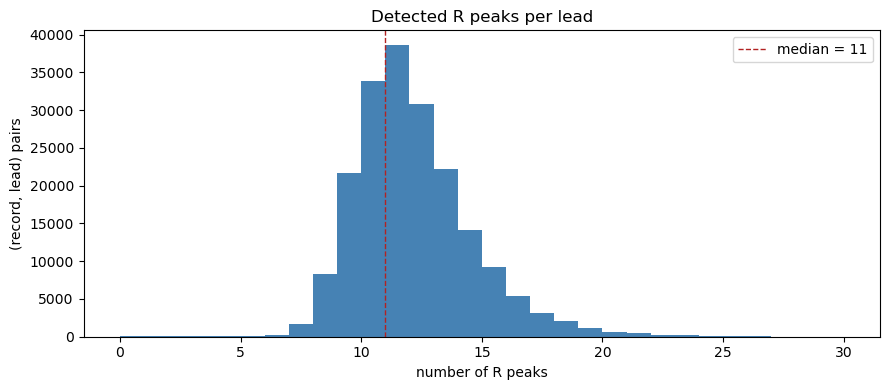

In [34]:
FEATURES = [c for c in features.columns if c != "label"]
lengths = features[FEATURES].map(len)

# Difficulty 1: "at some points, all the features for the particular subjects are NaN".
empty = features[FEATURES].map(
    lambda a: len(a) == 0 or bool(np.all(np.isnan(a)))).all(axis = 1)

print(f"Difficulty 1 - subjects with every feature NaN: {empty.sum():,} ({empty.mean():.1%})")

# Difficulty 2: "the length of extracted features for all the ECGs are not the same,
# which means all the recorded signals did not have equal no. of peaks".
# One count per (record, lead) pair, since each lead was delineated on its own.
n_beats = lengths[[c for c in FEATURES if c.endswith("R_loc")]].stack()

print(f"Difficulty 2 - distinct feature lengths: {n_beats.nunique()}"
      f"  (min {n_beats.min()}, median {int(n_beats.median())}, max {n_beats.max()})")

# Within one lead the sixteen features should share a length; check every lead.
ragged = pd.concat(
    [lengths[[c for c in FEATURES if c.startswith(f"{lead}_")]].nunique(axis = 1) > 1
     for lead in LEADS], axis = 1)

print(f"Also         - (record, lead) pairs whose 16 features disagree: "
      f"{int(ragged.to_numpy().sum()):,} of {ragged.size:,}")

print("\nmean share of NaN within each feature:")
print(features[FEATURES]
      .map(lambda a: float(np.mean(np.isnan(a))) if len(a) else 1.0)
      .mean().sort_values(ascending = False).round(3).to_string())


fig, ax = plt.subplots(figsize = (9, 4))

ax.hist(n_beats, bins = range(0, int(n_beats.max()) + 2), color = "steelblue")
ax.set_title("Detected R peaks per lead")
ax.set_xlabel("number of R peaks")
ax.set_ylabel("(record, lead) pairs")
ax.axvline(int(n_beats.median()), color = "firebrick", linestyle = "--", linewidth = 1,
           label = f"median = {int(n_beats.median())}")
ax.legend()

plt.tight_layout()
plt.show()

## Forward fill and length equating

The paper applies the fixes in a stated order: *"To deal with the missing values in the extracted feature, the Forward Fill (ffill) method has been implemented at this stage. Next, the length of extracted features for each ECG signal is equated."*

Forward fill therefore runs first, along the beat axis inside each record, which is the only axis available while the lists are still ragged. Lengths are then equated so the sixteen features can be stacked into the three-dimensional array, and that array is flattened to one row per subject.

The paper does not state the common length, so `N_BEATS` is set to the median peak count measured above. A second forward fill down the columns follows, because the first pass cannot repair the 280 subjects whose features are entirely NaN - the paper lists those as its first difficulty, and only an across-subject fill can reach them.

In [35]:
N_BEATS = int(n_beats.median())


def forward_fill(values):
    """Forward fill along the beat axis of one record."""
    if len(values) == 0:
        return values
    index = np.where(~np.isnan(values), np.arange(len(values)), 0)
    np.maximum.accumulate(index, out = index)
    return values[index]


def equate(values, length):
    """Truncate or pad one record to a common number of beats."""
    out = np.full(length, np.nan, dtype = np.float32)
    keep = min(len(values), length)
    if keep:
        out[:keep] = values[:keep]
        out[keep:] = values[keep - 1]     # forward fill past the last beat
    return out


cube = np.stack([
    np.stack([equate(forward_fill(features[c].iloc[i]), N_BEATS) for c in FEATURES])
    for i in range(len(features))
])

print(f"three-dimensional array: {cube.shape}  (subjects, features, beats)")

columns = [f"{c}_{k}" for c in FEATURES for k in range(N_BEATS)]
prepared = pd.DataFrame(cube.reshape(len(cube), -1), index = features.index,
                        columns = columns)

print(f"flattened:               {prepared.shape}")
print(f"NaN before column fill:  {prepared.isna().mean().mean():.2%}"
      f"   all-NaN subjects: {prepared.isna().all(axis = 1).sum()}")

prepared = prepared.ffill()

# Each lead's RR_0 is undefined, so forward fill has nothing to draw from.
dead = prepared.columns[prepared.isna().all()]
prepared = prepared.drop(columns = dead)

print(f"NaN after column fill:   {prepared.isna().sum().sum()}"
      f"   dropped all-NaN columns: {list(dead)}")
print(f"final feature matrix:    {prepared.shape}")

three-dimensional array: (16244, 192, 11)  (subjects, features, beats)
flattened:               (16244, 2112)
NaN before column fill:  1.09%   all-NaN subjects: 0
NaN after column fill:   0   dropped all-NaN columns: ['I_RR_0', 'II_RR_0', 'III_RR_0', 'aVR_RR_0', 'aVL_RR_0', 'aVF_RR_0', 'V1_RR_0', 'V2_RR_0', 'V3_RR_0', 'V4_RR_0', 'V5_RR_0', 'V6_RR_0']
final feature matrix:    (16244, 2100)


In [36]:
prepared

,I_P_loc_0,I_P_loc_1,I_P_loc_2,I_P_loc_3,I_P_loc_4,I_P_loc_5,I_P_loc_6,I_P_loc_7,I_P_loc_8,I_P_loc_9,...,V6_RR_1,V6_RR_2,V6_RR_3,V6_RR_4,V6_RR_5,V6_RR_6,V6_RR_7,V6_RR_8,V6_RR_9,V6_RR_10
ecg_id,,,,,,,,,,,,,,,,,,,,,
1,100.0,195.0,290.0,381.0,477.0,570.0,667.0,762.0,854.0,949.0,...,93.0,93.0,93.0,94.0,95.0,97.0,94.0,91.0,96.0,96.0
2,87.0,217.0,354.0,488.0,614.0,733.0,849.0,849.0,849.0,849.0,...,130.0,137.0,134.0,126.0,119.0,116.0,116.0,116.0,116.0,116.0
3,91.0,190.0,285.0,383.0,472.0,566.0,658.0,751.0,845.0,937.0,...,98.0,96.0,96.0,91.0,92.0,93.0,94.0,93.0,94.0,94.0
4,96.0,178.0,267.0,351.0,435.0,510.0,588.0,667.0,751.0,830.0,...,83.0,88.0,85.0,82.0,76.0,79.0,79.0,83.0,78.0,76.0
5,18.0,102.0,206.0,302.0,385.0,469.0,558.0,657.0,752.0,844.0,...,90.0,96.0,94.0,86.0,83.0,89.0,98.0,95.0,90.0,84.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21833,65.0,120.0,173.0,232.0,287.0,342.0,402.0,454.0,509.0,565.0,...,56.0,56.0,55.0,56.0,56.0,56.0,55.0,55.0,56.0,42.0
21834,92.0,180.0,270.0,360.0,450.0,537.0,628.0,719.0,809.0,898.0,...,88.0,89.0,90.0,89.0,88.0,91.0,91.0,90.0,89.0,89.0
21835,47.0,162.0,264.0,373.0,482.0,581.0,678.0,780.0,882.0,882.0,...,99.0,99.0,109.0,108.0,101.0,96.0,103.0,103.0,99.0,99.0


## Latent Feature extractors (CNN + Autoencoder)

## Learning curves

As we do not split into train and validation sets, the learning curves presented below can only show that our models are progressively learn from the data. However, whether they are overfitted to train data or not, complementary validation data must be evaluated at every epoch for more reliable conclusions.

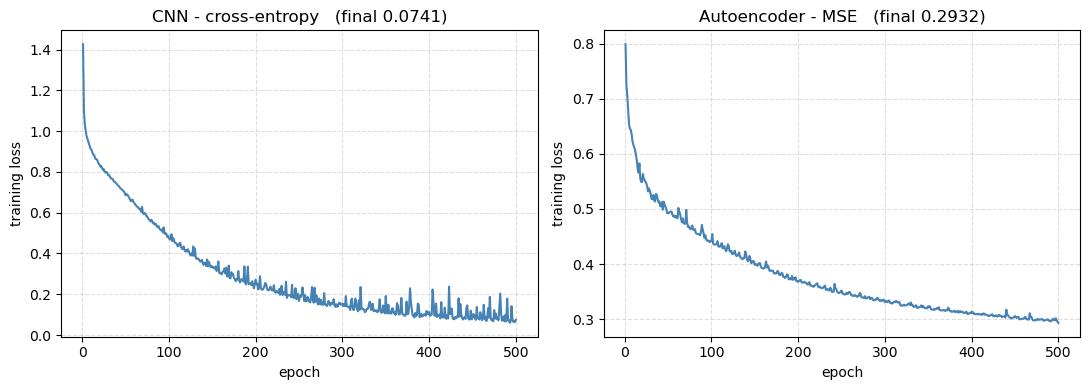

In [37]:
histories = {
    "CNN - cross-entropy": "checkpoints/cnn.pt",
    "Autoencoder - MSE": "checkpoints/ae16.pt",
}

fig, axes = plt.subplots(1, len(histories), figsize = (11, 4))

for ax, (title, path) in zip(axes, histories.items()):
    history = torch.load(path, map_location = "cpu")["loss_history"]

    ax.plot(range(1, len(history) + 1), history, color = "steelblue")
    ax.set_title(f"{title}   (final {history[-1]:.4f})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("training loss")
    ax.grid(True, linestyle = "--", alpha = 0.4)
    ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Feature compression

We compress the whole dataset and then split into train and test sets.

Note that, this action does not introduce data leakage to the train set, as we trained the components (`1D CNN` + `Autoencoder`) in our latent feature extractors using the train set.

A further note, as we call `train_test_split()` from `sklearn` using the same `random_state = 42`. This guarantees that we do not leak information into the training data.

Both extractors were trained by `train.py` on the HPC and are only *applied* here, frozen:

| checkpoint | trained on | gives |
| --- | --- | --- |
| `checkpoints/cnn.pt` | the raw `(12, 1000)` leads, cross-entropy | 125 features |
| `checkpoints/ae16.pt` | those 125 concatenated with the 2100 neurokit columns, MSE | 16 latent features |

The CNN's classifier head existed only to train its convolutions and is discarded; just
`feature_extractor` is used. The autoencoder's decoder is likewise discarded, and only
`encoder` is kept. The sixteen numbers it produces are what the classifiers below see -
the whole `1000 x 12` record, plus everything neurokit2 found in it, reduced to sixteen.

In [38]:
def latent_feature_extractor(
    records, neurokit, cnn = "checkpoints/cnn.pt",
    autoencoder = "checkpoints/ae16.pt", batch = 256
):

    def apply(model, data):
        with torch.no_grad():
            return np.concatenate([model(data[i:i + batch]).numpy()
                                   for i in range(0, len(data), batch)])

    # Lead-major (n, 12, 1000), as train.py fed the CNN, then its 125 features
    # concatenated with the neurokit columns in the same order train.py used.
    signals = np.ascontiguousarray(
        records.reshape(len(records), 1000, 12).transpose(0, 2, 1), dtype = np.float32)

    extractor = CNNFeatureExtractor()
    extractor.load_state_dict(torch.load(cnn, map_location = "cpu")["extractor"])
    matrix = np.hstack([neurokit.to_numpy(dtype = np.float32),
                        apply(extractor.eval(), torch.from_numpy(signals))])

    # The encoder, with the scaler that was fitted on its training rows.
    checkpoint = torch.load(autoencoder, map_location = "cpu")
    model = Autoencoder(input_dim = checkpoint["input_dim"],
                        latent_dim = checkpoint["latent_dim"])
    model.load_state_dict(checkpoint["model"])

    codes = apply(model.eval().encoder,
                  (torch.from_numpy(matrix) - checkpoint["scaler_mean"].float())
                  / checkpoint["scaler_scale"].float())

    latent = pd.DataFrame(codes, index = neurokit.index,
                        columns = [f"z{k}" for k in range(codes.shape[1])])

    print(f"neurokit + CNN {matrix.shape}  ->  encoder  ->  {latent.shape}")

    return latent


latent = latent_feature_extractor(X, prepared)

latent.head(2)

neurokit + CNN (16244, 2225)  ->  encoder  ->  (16244, 16)


,z0,z1,z2,z3,z4,z5,z6,z7,z8,z9,z10,z11,z12,z13,z14,z15
ecg_id,,,,,,,,,,,,,,,,
1,10.572054,16.230730,9.667310,-1.076325,-10.694835,-7.481009,-7.145177,5.791224,23.948353,-11.705867,6.729497,4.429910,-13.093295,-7.396569,-9.039445,5.044767
2,24.192471,15.897377,30.466574,32.012070,-34.051861,-57.613205,-24.963930,-20.640463,68.788589,-31.404549,39.719517,-24.270086,-68.070351,19.154284,-39.146610,15.265540


## Labels and train/test split

*"the set of all the n features for each subject is combined with respective labels with
the help of subject IDs. The labels or target variables are in string format; hence, it is
converted to the numeric data type by applying label encoding."*

In [39]:
LABEL_ENCODING = {"NORM": 0, "MI": 1, "STTC": 2, "HYP": 3, "CD": 4}

target = y.loc[latent.index].map(LABEL_ENCODING)

print("label encoding:")
for name, code in LABEL_ENCODING.items():
    print(f"  {code}  {name:5s} {(target == code).sum():,}")

X_train, X_test, y_train, y_test = train_test_split(
    latent, target, test_size = 0.2, random_state = 42)

print(f"\ntrain: {X_train.shape}   test: {X_test.shape}")

label encoding:
  0  NORM  9,069
  1  MI    2,532
  2  STTC  2,400
  3  HYP   535
  4  CD    1,708

train: (12995, 16)   test: (3249, 16)


## Train/test class distribution

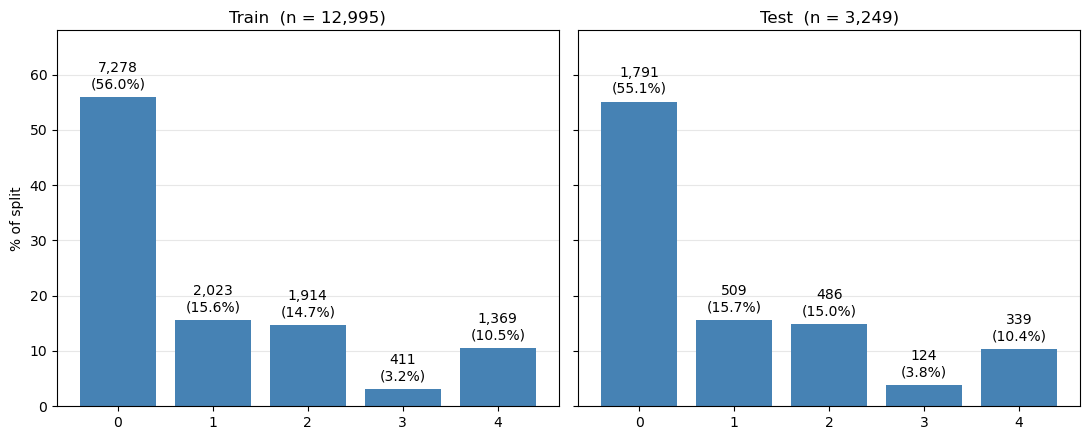

In [40]:
fig, axes = plt.subplots(1, 2, figsize = (11, 4.5), sharey = True)

for ax, (title, split) in zip(axes, [("Train", y_train), ("Test", y_test)]):
    counts = split.value_counts()
    shares = counts / len(split) * 100

    ax.bar(shares.index, shares.values, color = "steelblue")
    ax.set_title(f"{title}  (n = {len(split):,})")
    ax.set_xlabel("")
    ax.grid(axis = "y", alpha = 0.3)
    ax.set_axisbelow(True)

    for pos, share, count in zip(shares.index, shares.values, counts.values):
        ax.text(pos, share + 1, f"{count:,}\n({share:.1f}%)", ha = "center", va = "bottom")

axes[0].set_ylabel("% of split")
axes[0].set_ylim(0, 68)

plt.tight_layout()
plt.show()

# Data Augmentation

The pipeline below is what the Modeling section uses. An `imblearn` pipeline applies
`SMOTE` during `fit` but not during `predict`, so each fold is trained on resampled data
and scored on the untouched fold.

In [41]:
def augmented(classifier):
    """Scale, then oversample, then fit - refitted inside every fold."""
    return Pipeline([
        ("scaler", StandardScaler()),
        ("smote", SMOTE(random_state = 42)),
        ("classifier", classifier),
    ])

# Modeling

## Classifiers

The paper describes two incompatible protocols, so both are reproduced.

*"Training data has 80 % of the total data while testing data has 20 %"* (III.D) produces
the confusion matrices of Figure 7, while *"The mean of 10-fold cross-validation for all
five classifiers' performance is listed in Table 6, 7, 9, 10, and 11"* (IV) produces the
per-class tables. The per-class numbers you compare against are therefore the
cross-validated ones.

The five classifiers are those of III.F, all at library defaults since the paper reports no
hyperparameters. Every fit goes through the `augmented()` pipeline, so scaling and SMOTE
are refitted on the training portion alone.

In [42]:
# III.F: "five machine learning algorithms have used, which are KNN, RF, XG-Boost,
# Gradient Boost, and Cat-Boost". Defaults throughout; no tuning.
CLASSIFIERS = {
    "KNN": KNeighborsClassifier(),
    "RF": RandomForestClassifier(random_state = 42, n_jobs = -1),
    "XGBoost": XGBClassifier(random_state = 42, n_jobs = -1),
    "HistGradientBoost": HistGradientBoostingClassifier(random_state = 42),
    "CatBoost": CatBoostClassifier(random_state = 42, verbose = 0),
    "AdaBoost": AdaBoostClassifier(random_state = 42)
}

# Class codes, in the numeric order of Table 5.
CLASS_ORDER = sorted(LABEL_ENCODING.values())

## Single 80/20 split

In [43]:
holdout = {}

for name, classifier in CLASSIFIERS.items():
    started = time.perf_counter()

    pipeline = augmented(classifier)
    pipeline.fit(X_train, y_train)
    predicted = pipeline.predict(X_test)

    holdout[name] = {
        "accuracy": accuracy_score(y_test, predicted),
        "report": pd.DataFrame(classification_report(
            y_test, predicted, labels = CLASS_ORDER,
            output_dict = True, zero_division = 0)).T,
        "predicted": predicted,
        "proba": pipeline.predict_proba(X_test),
    }

    print(f"{name:14s} accuracy {holdout[name]['accuracy']:.3f}"
          f"   {time.perf_counter() - started:6.1f}s")

KNN            accuracy 0.557      0.2s
RF             accuracy 0.668      1.5s
XGBoost        accuracy 0.667      0.8s
HistGradientBoost accuracy 0.649      5.3s
CatBoost       accuracy 0.666      6.1s
AdaBoost       accuracy 0.540      2.9s


## 10-fold cross-validation

Metrics are averaged across folds, matching *"The mean of 10-fold cross-validation"*.
The paper does not stratify, so `KFold` is used rather than `StratifiedKFold`.

In [44]:
FOLDS = 10


def cross_validate(classifier, X, y, folds = FOLDS):
    """Mean per-class precision, recall and F1 over the folds."""
    kfold = KFold(n_splits = folds, shuffle = True, random_state = 42)
    scores, accuracies = [], []

    for train_index, validation_index in kfold.split(X):
        pipeline = augmented(classifier)
        pipeline.fit(X.iloc[train_index], y.iloc[train_index])
        predicted = pipeline.predict(X.iloc[validation_index])

        actual = y.iloc[validation_index]
        precision, recall, f1, _ = precision_recall_fscore_support(
            actual, predicted, labels = CLASS_ORDER, zero_division = 0)

        scores.append(np.vstack([precision, recall, f1]))
        accuracies.append(accuracy_score(actual, predicted))

    table = pd.DataFrame(np.mean(scores, axis = 0).T, index = CLASS_ORDER,
                         columns = ["precision", "recall", "f1"])
    return table, float(np.mean(accuracies)), float(np.std(accuracies))


crossvalidated = {}

for name, classifier in CLASSIFIERS.items():
    started = time.perf_counter()

    table, mean_accuracy, std_accuracy = cross_validate(classifier, latent, target)
    crossvalidated[name] = {"report": table, "accuracy": mean_accuracy,
                            "accuracy_std": std_accuracy}

    print(f"{name:14s} accuracy {mean_accuracy:.3f} +/- {std_accuracy:.3f}"
          f"   {time.perf_counter() - started:6.1f}s")

KNN            accuracy 0.569 +/- 0.011      0.9s
RF             accuracy 0.691 +/- 0.008     17.4s
XGBoost        accuracy 0.677 +/- 0.011      9.2s
HistGradientBoost accuracy 0.671 +/- 0.013     52.8s
CatBoost       accuracy 0.684 +/- 0.010     57.2s
AdaBoost       accuracy 0.554 +/- 0.013     33.0s


# Reproduced results

Each output below corresponds to one artefact in the paper.

| here | paper |
| --- | --- |
| per-class table | Tables 6, 7, 9, 10, 11 (10-fold means) |
| summary table | Table 12 (classifier comparison) |
| confusion matrix | Figure 7 (20 % holdout) |
| ROC curves | Figure 8 (class-wise ROC-AUC) |

The per-class table comes from cross-validation and the confusion matrix from the
holdout, because that is how the paper produced each of them.

In [45]:
# Tables 6, 7, 9, 10, 11 - per-class precision, recall and F1, averaged over folds.
per_class = pd.concat({name: result["report"] for name, result in crossvalidated.items()},
                      names = ["classifier", "class"])

(per_class * 100).round(1)

precision  recall    f1
classifier        class                         
KNN               0           81.8    61.5  70.2
                  1           39.0    43.9  41.3
                  2           40.3    49.1  44.2
                  3           18.4    50.4  26.9
                  4           50.9    64.9  56.9
RF                0           82.6    80.8  81.7
                  1           51.4    50.8  51.1
                  2           51.8    51.4  51.5
                  3           30.3    38.4  33.7
                  4           64.3    68.2  66.1
XGBoost           0           85.6    74.7  79.7
                  1           48.4    53.4  50.8
                  2           52.2    60.0  55.7
                  3           28.4    46.6  35.2
                  4           62.5    69.6  65.8
HistGradientBoost 0           87.2    73.1  79.5
                  1           48.2    53.8  50.8
                  2           50.8    59.6  54.8
                  3           26.6    51.9  35.1
                  4           61.5    70.2  65.5
CatBoost          0           86.5    75.0  80.3
                  1           49.6    54.3  51.8
                  2           52.2    60.2  55.9
                  3           28.9    52.8  37.3
                  4           64.1    69.9  66.8
AdaBoost          0           82.7    64.1  72.2
                  1           37.4    39.7  38.4
                  2           37.2    41.8  39.1
                  3           14.1    47.2  21.7
                  4           46.4    54.0  49.6

In [46]:
# Table 12 - one row per classifier.
summary = pd.DataFrame({
    name: {
        "accuracy": result["accuracy"],
        "accuracy_std": result["accuracy_std"],
        "precision": result["report"]["precision"].mean(),
        "recall": result["report"]["recall"].mean(),
        "f1": result["report"]["f1"].mean(),
    }
    for name, result in crossvalidated.items()
}).T.sort_values("f1", ascending = False)

(summary * 100).round(1)

,accuracy,accuracy_std,precision,recall,f1
CatBoost,68.4,1.0,56.3,62.5,58.4
XGBoost,67.7,1.1,55.4,60.8,57.5
HistGradientBoost,67.1,1.3,54.8,61.7,57.1
RF,69.1,0.8,56.1,57.9,56.8
KNN,56.9,1.1,46.1,53.9,47.9
AdaBoost,55.4,1.3,43.6,49.3,44.2


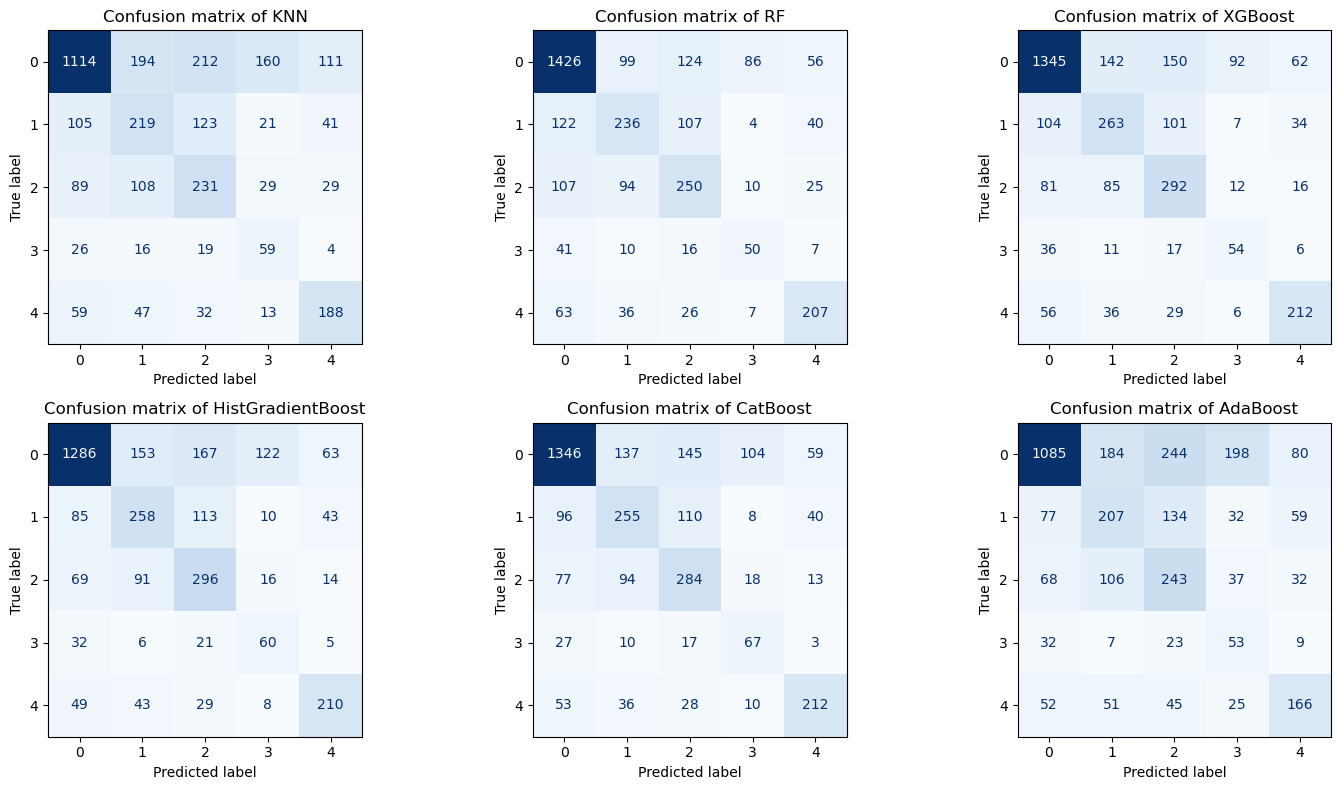

In [47]:
# Figure 7 - confusion matrices on the 20 % holdout, in sample counts.
fig, axes = plt.subplots(2, 3, figsize = (15, 8),
                         squeeze = False)

for ax, (name, result) in zip(axes.ravel(), holdout.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, result["predicted"], labels = CLASS_ORDER,
        values_format = "d", cmap = "Blues", colorbar = False, ax = ax)
    ax.set_title(f"Confusion matrix of {name}")

plt.tight_layout()
plt.show()

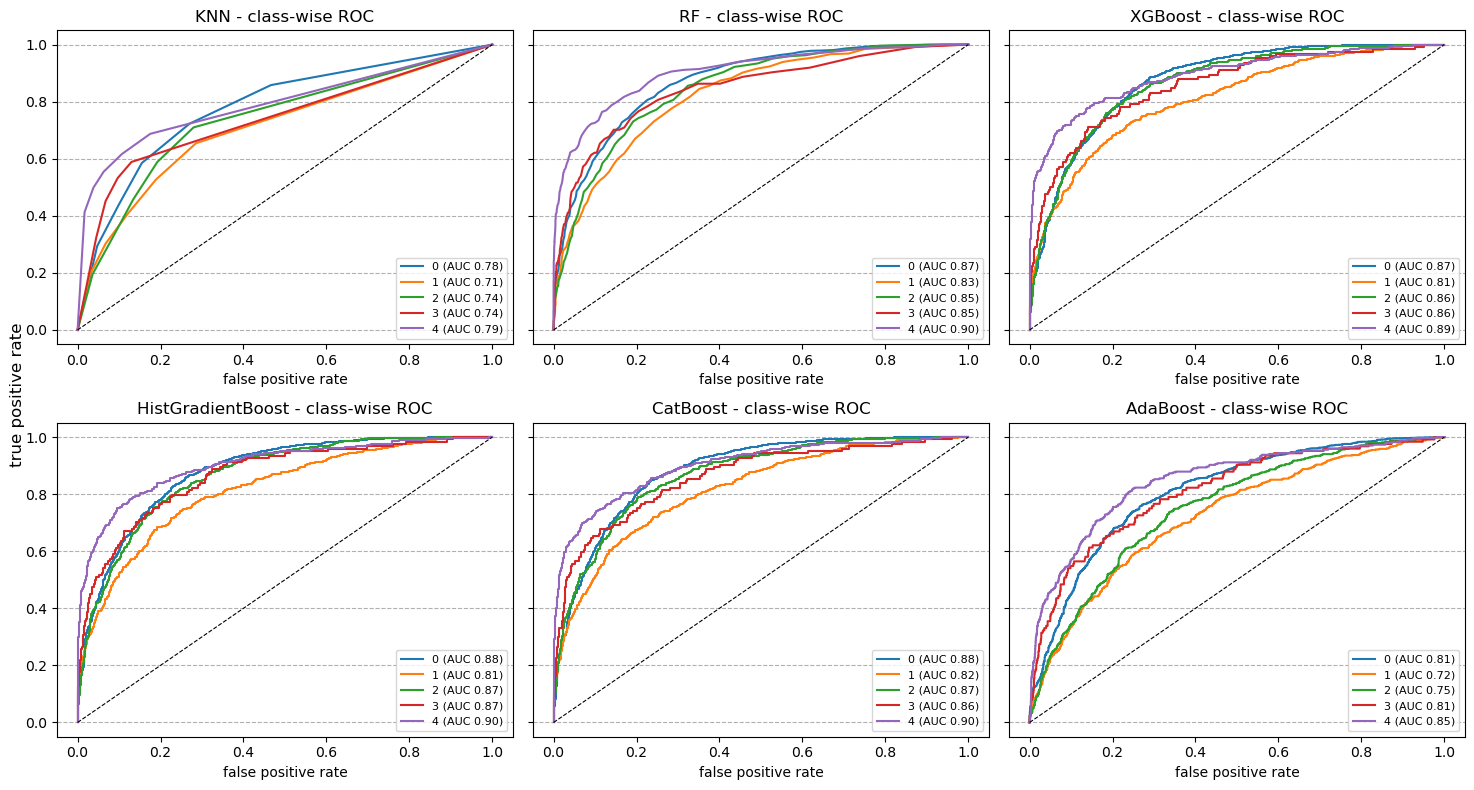

,KNN,RF,XGBoost,HistGradientBoost,CatBoost,AdaBoost
0,0.781,0.871,0.872,0.877,0.880,0.810
1,0.711,0.826,0.810,0.815,0.815,0.724
2,0.738,0.848,0.864,0.866,0.866,0.752
3,0.740,0.847,0.856,0.866,0.861,0.811
4,0.792,0.904,0.892,0.901,0.900,0.848


In [48]:
# Figure 8 - class-wise ROC, one-vs-rest, on the 20 % holdout.
actual = label_binarize(y_test, classes = CLASS_ORDER)

fig, axes = plt.subplots(2, 3, figsize = (15, 8),
                         squeeze = False, sharey = True)

roc_scores = {}

for ax, (name, result) in zip(axes.ravel(), holdout.items()):
    scores = {}
    for k, label in enumerate(CLASS_ORDER):
        false_positive, true_positive, _ = roc_curve(actual[:, k], result["proba"][:, k])
        area = auc(false_positive, true_positive)
        scores[label] = area
        ax.plot(false_positive, true_positive, label = f"{label} (AUC {area:.2f})")

    roc_scores[name] = scores
    ax.plot([0, 1], [0, 1], "k--", linewidth = 0.8)
    ax.set_title(f"{name} - class-wise ROC")
    ax.set_xlabel("false positive rate")
    ax.grid(True, axis = "y", linestyle = "--")
    ax.legend(loc = "lower right", fontsize = 8)

fig.supylabel("true positive rate")
plt.tight_layout()
plt.show()

pd.DataFrame(roc_scores).round(3)